<a href="https://colab.research.google.com/github/Sneha-1503/AI-Based-Mental-Health-Monitoring-Solution/blob/main/AI_Based_Mental_Health_Monitoring_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [3]:
from google.colab import files

uploaded = files.upload()


Saving Mental Health Dataset.csv to Mental Health Dataset.csv


In [4]:
df = pd.read_csv("Mental Health Dataset.csv")

In [5]:
print(df.isnull().sum())

Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64


In [6]:
df = df.dropna()

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate Rows: 2304


In [8]:
df = df.drop(columns=["Timestamp"])

In [9]:
print(df.columns)

Index(['Gender', 'Country', 'Occupation', 'self_employed', 'family_history',
       'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits',
       'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles',
       'Work_Interest', 'Social_Weakness', 'mental_health_interview',
       'care_options'],
      dtype='object')


In [10]:
X = df.drop(columns=["treatment"])
y = df["treatment"]


In [11]:
X = pd.get_dummies(X, drop_first=True)

In [12]:
print(X.head())

   Gender_Male  Country_Belgium  Country_Bosnia and Herzegovina  \
3        False            False                           False   
4        False            False                           False   
5        False            False                           False   
6        False            False                           False   
7        False            False                           False   

   Country_Brazil  Country_Canada  Country_Colombia  Country_Costa Rica  \
3           False           False             False               False   
4           False           False             False               False   
5           False           False             False               False   
6           False           False             False               False   
7           False           False             False               False   

   Country_Croatia  Country_Czech Republic  Country_Denmark  ...  \
3            False                   False            False  ...   
4         

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [14]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (227886, 62)
Testing Data: (56972, 62)


In [15]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [16]:
y_pred = model.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.741276416485291


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.76      0.70      0.73     28306
         Yes       0.73      0.78      0.75     28666

    accuracy                           0.74     56972
   macro avg       0.74      0.74      0.74     56972
weighted avg       0.74      0.74      0.74     56972



In [19]:
print(confusion_matrix(y_test, y_pred))

[[19830  8476]
 [ 6264 22402]]


In [20]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                       Feature  Importance
40          family_history_Yes    0.236740
61            care_options_Yes    0.132310
60       care_options_Not sure    0.065492
39           self_employed_Yes    0.063019
58  mental_health_interview_No    0.048992
0                  Gender_Male    0.045992
33      Country_United Kingdom    0.030288
34       Country_United States    0.029384
4               Country_Canada    0.025822
16             Country_Ireland    0.024362


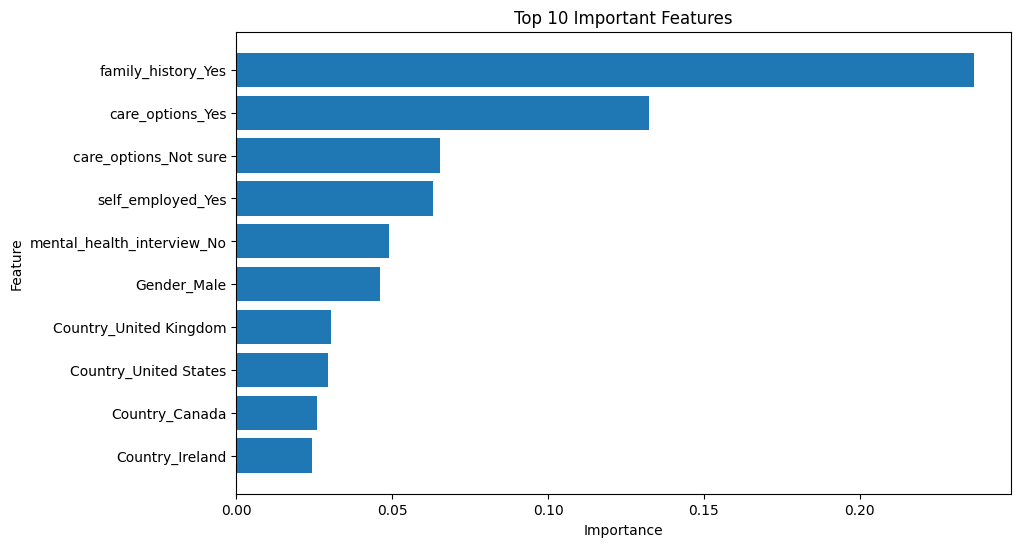

In [21]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [26]:
joblib.dump(model, "mental_health_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [23]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [29]:
from google.colab import files

files.download("mental_health_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
from google.colab import files
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>